In [ ]:
# -*- coding: utf-8 -*-
"""
Quarter_Geom_Lsymm.py

PINN for Steady-State Heat Equation on Quarter Annulus
======================================================
Symmetry enforcement via volumetric L_symm operator instead of Neumann BCs.

Domain: First quadrant (x >= 0, y >= 0), R1 <= r <= R2
PDE: nabla^2 T = 0 (Laplace equation)
BCs:
  - Inner arc (r = R1): T = T_cold (Dirichlet)
  - Outer arc (r = R2): T = T_hot  (Dirichlet)
  - Symmetry: enforced via L_symm = x*dT/dy - y*dT/dx = 0 throughout interior

Symmetry operator:
  L_symm = x*dT/dy - y*dT/dx = r * dT/dtheta
  This is the angular derivative of T scaled by r.
  It is identically zero iff T = T(r), i.e. T has no angular variation.
  Enforcing L_symm = 0 as a soft volumetric loss replaces the Neumann BCs
  (dT/dx = 0 at x=0, dT/dy = 0 at y=0), which are consequences of radial
  symmetry and therefore implied by L_symm = 0.

Normalization scheme (consistent with Full_Geom.py):
  - Inputs:       x_norm = x / L_char,  y_norm = y / L_char
  - Output:       T = T_mean + (T_range/2) * network_output
  - PDE loss:     laplacian / (T_range / L_char^2)       -> dimensionless
  - Dirichlet BC: (T - T_target) / T_range               -> dimensionless
  - L_symm loss:  (x*dT/dy - y*dT/dx) / T_range         -> dimensionless
    Rationale: [x*dT/dy] = L * (T/L) = T, so T_range is the correct scale.
    This places L_symm on the same footing as Dirichlet BC residuals.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time
from typing import Tuple


# =============================================================================
# CONFIGURATION
# =============================================================================

In [ ]:


class Config:
    """Configuration container for quarter annulus with L_symm."""

    def __init__(
        self,
        R1: float = 1.0,
        R2: float = 3.0,
        T_cold: float = 100.0,
        T_hot: float = 500.0,
        hidden_layers: int = 4,
        neurons_per_layer: int = 32,
        adam_iterations: int = 10000,
        lbfgs_iterations: int = 3000,
        adam_lr: float = 1e-3,
        lambda_pde: float = 1.0,
        lambda_bc: float = 10.0,
        lambda_symm: float = 5.0,   # Weight for L_symm loss
        # Interior points increased vs Neumann version since interior now
        # carries both PDE and symmetry residuals
        n_interior: int = 600,
        n_boundary_inner: int = 75,
        n_boundary_outer: int = 75,
        batch_size: int = 175,
        resample_every: int = 100,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        # Geometry
        self.R1 = R1
        self.R2 = R2

        # Boundary conditions
        self.T_cold = T_cold
        self.T_hot = T_hot

        # Network architecture
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer

        # Training parameters
        self.adam_iterations = adam_iterations
        self.lbfgs_iterations = lbfgs_iterations
        self.adam_lr = adam_lr

        # Loss weights
        self.lambda_pde = lambda_pde
        self.lambda_bc = lambda_bc
        self.lambda_symm = lambda_symm

        # Sampling points
        self.n_interior = n_interior
        self.n_boundary_inner = n_boundary_inner
        self.n_boundary_outer = n_boundary_outer

        # Training settings
        self.batch_size = batch_size
        self.resample_every = resample_every
        self.device = device

        # Derived normalization quantities (consistent with Full_Geom.py)
        self.T_range = T_hot - T_cold
        self.T_mean = (T_hot + T_cold) / 2.0
        self.L_char = R2

    def __repr__(self):
        return f"""
Configuration (Quarter Annulus + L_symm):
------------------------------------------
Geometry: R1={self.R1}, R2={self.R2}
BCs: T_cold={self.T_cold}, T_hot={self.T_hot}
Network: {self.hidden_layers} layers x {self.neurons_per_layer} neurons
Training: Adam({self.adam_iterations}) -> L-BFGS({self.lbfgs_iterations})
Weights: lambda_pde={self.lambda_pde}, lambda_bc={self.lambda_bc}, lambda_symm={self.lambda_symm}
Points: interior={self.n_interior}, inner={self.n_boundary_inner}, outer={self.n_boundary_outer}
Symmetry: enforced via L_symm = x*dT/dy - y*dT/dx in interior (no Neumann BCs)
Device: {self.device}
"""



# =============================================================================
# NEURAL NETWORK
# =============================================================================

In [ ]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for quarter annulus.

    Identical architecture to Full_Geom.py and Neumann Quarter version.
    Input normalization divides by L_char; quarter domain maps [0, R2] -> [0, 1].
    Output scaling: T = T_mean + (T_range/2) * network_output.
    """

    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        layers = []

        # Input layer
        layers.append(nn.Linear(2, config.neurons_per_layer))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(config.hidden_layers - 1):
            layers.append(nn.Linear(config.neurons_per_layer, config.neurons_per_layer))
            layers.append(nn.Tanh())

        # Output layer (linear — no activation)
        layers.append(nn.Linear(config.neurons_per_layer, 1))

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        """Xavier initialization; last layer outputs near zero -> T starts near T_mean."""
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

        last_linear = list(self.network.children())[-1]
        nn.init.zeros_(last_linear.weight)
        last_linear.bias.data.fill_(0.0)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Forward pass: normalize inputs, scale output to physical temperature."""
        if x.dim() == 1:
            x = x.unsqueeze(1)
        if y.dim() == 1:
            y = y.unsqueeze(1)

        # Input normalization (consistent with Full_Geom.py)
        x_norm = x / self.config.L_char
        y_norm = y / self.config.L_char

        inputs = torch.cat([x_norm, y_norm], dim=1)
        u_normalized = self.network(inputs)

        # Output scaling (consistent with Full_Geom.py)
        u = self.config.T_mean + (self.config.T_range / 2.0) * u_normalized

        return u



# =============================================================================
# SAMPLER
# =============================================================================

In [ ]:
class Sampler:
    """
    Sampling utilities for quarter annular domain.
    No symmetry boundary samplers — L_symm is enforced on interior points.
    """

    def __init__(self, config: Config):
        self.config = config
        self.device = config.device

    def sample_interior_lhs(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sample interior points using Latin Hypercube Sampling.
        Uniform area distribution over quarter annulus (theta in [0, pi/2]).
        """
        sampler = qmc.LatinHypercube(d=2, seed=None)
        samples = sampler.random(n=n_points)

        r_squared = self.config.R1**2 + samples[:, 0] * (self.config.R2**2 - self.config.R1**2)
        r = np.sqrt(r_squared)
        theta = samples[:, 1] * (np.pi / 2)

        x = r * np.cos(theta)
        y = r * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_inner(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on inner arc (r = R1), theta in [0, pi/2], with jitter."""
        theta = np.linspace(0, np.pi/2, n_points, endpoint=False)
        theta += np.random.uniform(0, (np.pi/2) / n_points, n_points)

        x = self.config.R1 * np.cos(theta)
        y = self.config.R1 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_outer(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on outer arc (r = R2), theta in [0, pi/2], with jitter."""
        theta = np.linspace(0, np.pi/2, n_points, endpoint=False)
        theta += np.random.uniform(0, (np.pi/2) / n_points, n_points)

        x = self.config.R2 * np.cos(theta)
        y = self.config.R2 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_all(self) -> dict:
        """Sample all training points. No symmetry boundary points needed."""
        return {
            'interior': self.sample_interior_lhs(self.config.n_interior),
            'inner':    self.sample_boundary_inner(self.config.n_boundary_inner),
            'outer':    self.sample_boundary_outer(self.config.n_boundary_outer),
        }


# =============================================================================
# PHYSICS
# =============================================================================

In [ ]:
class Physics:
    """
    Physics computations for quarter annulus with L_symm symmetry enforcement.

    All residuals normalized to O(1) for balanced gradients:

      Residual       |  Raw units  |  Normalization scale       |  Normalized
      ---------------|-------------|----------------------------|-------------
      PDE (Laplacian)|  T / L^2    |  T_range / L_char^2        |  O(1)
      Dirichlet BC   |  T          |  T_range                   |  O(1)
      L_symm         |  T          |  T_range                   |  O(1)

    L_symm normalization rationale:
      [x * dT/dy] = L * (T/L) = T  =>  normalize by T_range.
      This is identical to Dirichlet BC normalization, which is correct:
      both measure temperature-scale deviations from the desired state.
    """

    def __init__(self, config: Config, model: PINN):
        self.config = config
        self.model = model

        # Normalization scales (all consistent with Full_Geom.py)
        self.pde_scale  = config.T_range / config.L_char**2   # Laplacian scale
        self.T_scale    = config.T_range                       # Dirichlet BC scale
        self.symm_scale = config.T_range                       # L_symm scale (same units as T)

    def compute_pde_residual(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Normalized Laplacian: (d^2T/dx^2 + d^2T/dy^2) / pde_scale
        Consistent with Full_Geom.py.
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        d2u_dx2 = torch.autograd.grad(
            du_dx, x, grad_outputs=torch.ones_like(du_dx),
            create_graph=True, retain_graph=True
        )[0]

        d2u_dy2 = torch.autograd.grad(
            du_dy, y, grad_outputs=torch.ones_like(du_dy),
            create_graph=True, retain_graph=True
        )[0]

        laplacian = d2u_dx2 + d2u_dy2
        return laplacian / self.pde_scale

    def compute_lsymm_residual(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Normalized angular symmetry residual:
          L_symm = (x * dT/dy - y * dT/dx) / T_range

        In polar coordinates: L_symm = r * dT/dtheta.
        Zero iff T has no angular variation, i.e. T = T(r).

        This is computed on interior points and replaces the Neumann BCs
        at x=0 and y=0, which are implied by radial symmetry.

        Note: x and y must already require grad for the graph to be connected.
        We set requires_grad here to be safe, but the caller should be aware
        that these tensors will have grad enabled after this call.
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        # L_symm = x * dT/dy - y * dT/dx  (units: T)
        lsymm = x.squeeze() * du_dy.squeeze() - y.squeeze() * du_dx.squeeze()

        return lsymm / self.symm_scale

    def compute_bc_residual_inner(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Normalized Dirichlet BC at inner arc: (T - T_cold) / T_range."""
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_cold) / self.T_scale

    def compute_bc_residual_outer(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Normalized Dirichlet BC at outer arc: (T - T_hot) / T_range."""
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_hot) / self.T_scale

# =============================================================================
# TRAINER
# =============================================================================

In [ ]:


class Trainer:
    """Training loop: Adam -> L-BFGS, with PDE + Dirichlet BC + L_symm losses."""

    def __init__(self, config: Config, model: PINN):
        self.config = config
        self.model = model
        self.sampler = Sampler(config)
        self.physics = Physics(config, model)

        self.history = {
            'total_loss': [], 'pde_loss': [],
            'bc_inner_loss': [], 'bc_outer_loss': [],
            'symm_loss': [],
            'iterations': []
        }
        self.current_iteration = 0
        self.training_time = 0.0

    def compute_losses(
        self, data: dict
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Compute all four loss components.

        Interior points are used for BOTH PDE and L_symm residuals.
        This is efficient since both require the same first-order derivatives;
        PyTorch's autograd graph is shared between the two computations.

        Important: compute_pde_residual and compute_lsymm_residual both call
        requires_grad_(True) internally, so we pass fresh tensors from data
        each time to avoid graph accumulation issues.
        """
        x_int, y_int = data['interior']

        # PDE loss (normalized Laplacian)
        residual_pde = self.physics.compute_pde_residual(x_int, y_int)
        loss_pde = torch.mean(residual_pde**2)

        # L_symm loss (normalized angular derivative) — same interior points
        residual_symm = self.physics.compute_lsymm_residual(x_int, y_int)
        loss_symm = torch.mean(residual_symm**2)

        # Dirichlet BC losses (normalized)
        x_inner, y_inner = data['inner']
        bc_inner = self.physics.compute_bc_residual_inner(x_inner, y_inner)
        loss_bc_inner = torch.mean(bc_inner**2)

        x_outer, y_outer = data['outer']
        bc_outer = self.physics.compute_bc_residual_outer(x_outer, y_outer)
        loss_bc_outer = torch.mean(bc_outer**2)

        return loss_pde, loss_bc_inner, loss_bc_outer, loss_symm

    def compute_total_loss(
        self, loss_pde, loss_bc_inner, loss_bc_outer, loss_symm
    ) -> torch.Tensor:
        """Weighted sum of all loss components."""
        return (
            self.config.lambda_pde  * loss_pde +
            self.config.lambda_bc   * (loss_bc_inner + loss_bc_outer) +
            self.config.lambda_symm * loss_symm
        )

    def get_minibatch(self, data: dict, batch_idx: int) -> dict:
        """Minibatch interior points; boundary points always use full set."""
        bs = self.config.batch_size
        x_int, y_int = data['interior']
        n_int = x_int.shape[0]
        start = (batch_idx * bs) % n_int
        end = min(start + bs, n_int)

        return {
            'interior': (x_int[start:end], y_int[start:end]),
            'inner':    data['inner'],
            'outer':    data['outer'],
        }

    def record(self, total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_symm):
        """Append current losses to history."""
        self.current_iteration += 1
        self.history['total_loss'].append(total_loss.item())
        self.history['pde_loss'].append(loss_pde.item())
        self.history['bc_inner_loss'].append(loss_bc_inner.item())
        self.history['bc_outer_loss'].append(loss_bc_outer.item())
        self.history['symm_loss'].append(loss_symm.item())
        self.history['iterations'].append(self.current_iteration)

    def train_adam(self):
        """Phase 1: Adam with cosine annealing learning rate schedule."""
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.config.adam_lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.config.adam_iterations, eta_min=1e-6
        )

        print("=" * 65)
        print("Phase 1: Adam Optimization")
        print("=" * 65)

        data = self.sampler.sample_all()
        n_batches = max(1, self.config.n_interior // self.config.batch_size)

        for iteration in range(self.config.adam_iterations):
            if iteration > 0 and iteration % self.config.resample_every == 0:
                data = self.sampler.sample_all()

            minibatch = self.get_minibatch(data, iteration % n_batches)

            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer, loss_symm = self.compute_losses(minibatch)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer, loss_symm)

            total_loss.backward()
            optimizer.step()
            scheduler.step()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_symm)

            if iteration % 1000 == 0 or iteration == self.config.adam_iterations - 1:
                lr = scheduler.get_last_lr()[0]
                print(f"Iter {iteration:5d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e} | "
                      f"Symm: {loss_symm.item():.2e} | "
                      f"LR: {lr:.1e}")

    def train_lbfgs(self):
        """Phase 2: L-BFGS with strong Wolfe line search."""
        print("\n" + "=" * 65)
        print("Phase 2: L-BFGS Optimization")
        print("=" * 65)

        optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=20,
            max_eval=25,
            history_size=100,
            tolerance_grad=1e-12,
            tolerance_change=1e-14,
            line_search_fn='strong_wolfe'
        )

        data = self.sampler.sample_all()
        iteration = [0]

        def closure():
            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer, loss_symm = self.compute_losses(data)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer, loss_symm)
            total_loss.backward()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_symm)
            iteration[0] += 1

            if iteration[0] % 200 == 0:
                print(f"L-BFGS Iter {iteration[0]:4d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e} | "
                      f"Symm: {loss_symm.item():.2e}")

            return total_loss

        for _ in range(self.config.lbfgs_iterations // 20):
            optimizer.step(closure)
            if iteration[0] % 500 == 0:
                data = self.sampler.sample_all()

    def train(self):
        """Full training pipeline: Adam then L-BFGS."""
        start_time = time.time()
        self.train_adam()
        self.train_lbfgs()
        self.training_time = time.time() - start_time

        print("\n" + "=" * 65)
        print(f"Training Complete!")
        print(f"Total time:  {self.training_time:.2f} seconds")
        print(f"Final loss:  {self.history['total_loss'][-1]:.2e}")
        print("=" * 65)



# =============================================================================
# ANALYTICS
# =============================================================================


In [ ]:
class Analytics:
    """Analytical solution (radially symmetric) and error metrics."""

    def __init__(self, config: Config):
        self.config = config

    def exact_solution(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        T(r) = T_cold + (T_hot - T_cold) * ln(r/R1) / ln(R2/R1)
        Valid for the full annulus; radial symmetry makes it exact for
        the quarter domain as well.
        """
        r = torch.sqrt(x**2 + y**2)
        r = torch.clamp(r, min=self.config.R1, max=self.config.R2)
        log_ratio = torch.log(r / self.config.R1) / np.log(self.config.R2 / self.config.R1)
        return self.config.T_cold + (self.config.T_hot - self.config.T_cold) * log_ratio

    def compute_l2_error(self, model: PINN, n_test: int = 10000) -> Tuple[float, float]:
        """Absolute and relative L2 errors on interior test points."""
        model.eval()
        sampler = Sampler(self.config)
        x_test, y_test = sampler.sample_interior_lhs(n_test)

        with torch.no_grad():
            u_pred  = model(x_test, y_test).squeeze()
            u_exact = self.exact_solution(x_test, y_test)

            l2_error  = torch.sqrt(torch.mean((u_pred - u_exact)**2))
            l2_exact  = torch.sqrt(torch.mean(u_exact**2))
            rel_error = (l2_error / l2_exact).item()
            abs_error = l2_error.item()

        model.train()
        return abs_error, rel_error

    def compute_lsymm_error(self, model: PINN, n_test: int = 5000) -> float:
        """
        Measure how well L_symm = 0 is satisfied on test interior points.
        Returns RMS of (x*dT/dy - y*dT/dx) / T_range.
        A well-trained model should drive this toward zero.
        """
        model.eval()
        sampler = Sampler(self.config)
        x_test, y_test = sampler.sample_interior_lhs(n_test)
        x_test = x_test.requires_grad_(True)
        y_test = y_test.requires_grad_(True)

        u = model(x_test, y_test)

        du_dx = torch.autograd.grad(
            u, x_test, grad_outputs=torch.ones_like(u),
            create_graph=False, retain_graph=True
        )[0]
        du_dy = torch.autograd.grad(
            u, y_test, grad_outputs=torch.ones_like(u),
            create_graph=False, retain_graph=False
        )[0]

        lsymm = x_test.squeeze() * du_dy.squeeze() - y_test.squeeze() * du_dx.squeeze()
        rms = torch.sqrt(torch.mean((lsymm / self.config.T_range)**2)).item()

        model.train()
        return rms

# =============================================================================
# VISUALIZATION
# =============================================================================

In [ ]:
class Visualizer:
    """Plotting utilities for quarter annulus with L_symm diagnostics."""

    def __init__(self, config: Config):
        self.config = config

    def _make_grid(self, n_grid: int):
        """Build meshgrid and annular mask for quarter domain."""
        x = np.linspace(0, self.config.R2, n_grid)
        y = np.linspace(0, self.config.R2, n_grid)
        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)
        return X, Y, mask

    def plot_solution(self, model: PINN, analytics: Analytics, n_grid: int = 100):
        """Predicted vs exact temperature and pointwise absolute error."""
        model.eval()
        X, Y, mask = self._make_grid(n_grid)

        X_t = torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            U_pred  = model(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)
            U_exact = analytics.exact_solution(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)

        U_pred_m  = np.where(mask, U_pred, np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error     = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        vmin, vmax = self.config.T_cold, self.config.T_hot

        im1 = axes[0].contourf(X, Y, U_pred_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[0].set_title('Predicted Solution (Quarter)', fontsize=14)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0], label='Temperature')

        im2 = axes[1].contourf(X, Y, U_exact_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[1].set_title('Exact Solution', fontsize=14)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1], label='Temperature')

        im3 = axes[2].contourf(X, Y, Error, levels=50, cmap='viridis')
        axes[2].set_title('Absolute Error |T_pred - T_exact|', fontsize=14)
        axes[2].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2], label='|Error|')

        theta = np.linspace(0, np.pi/2, 100)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.plot([self.config.R1, self.config.R2], [0, 0], 'k--', lw=0.8, alpha=0.5)
            ax.plot([0, 0], [self.config.R1, self.config.R2], 'k--', lw=0.8, alpha=0.5)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.suptitle('Quarter Annulus PINN with L_symm Enforcement', fontsize=13)
        plt.tight_layout()
        plt.show()
        model.train()

    def plot_lsymm_field(self, model: PINN, n_grid: int = 100):
        """
        Plot the L_symm field = (x*dT/dy - y*dT/dx) / T_range over the domain.
        Should be near zero everywhere if symmetry is well enforced.
        """
        model.eval()
        X, Y, mask = self._make_grid(n_grid)

        X_t = torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)
        X_t = X_t.requires_grad_(True)
        Y_t = Y_t.requires_grad_(True)

        u = model(X_t, Y_t)

        du_dx = torch.autograd.grad(
            u, X_t, grad_outputs=torch.ones_like(u),
            create_graph=False, retain_graph=True
        )[0]
        du_dy = torch.autograd.grad(
            u, Y_t, grad_outputs=torch.ones_like(u),
            create_graph=False
        )[0]

        lsymm = (X_t.squeeze() * du_dy.squeeze() - Y_t.squeeze() * du_dx.squeeze())
        lsymm_norm = (lsymm / self.config.T_range).detach().cpu().numpy().reshape(n_grid, n_grid)
        lsymm_m = np.where(mask, lsymm_norm, np.nan)

        fig, ax = plt.subplots(figsize=(6, 5))
        vabs = np.nanmax(np.abs(lsymm_m))
        im = ax.contourf(X, Y, lsymm_m, levels=50, cmap='RdBu_r',
                         vmin=-vabs, vmax=vabs)
        plt.colorbar(im, ax=ax, label='L_symm / T_range')
        ax.set_title('Symmetry Residual Field\n(x·dT/dy − y·dT/dx) / T_range', fontsize=13)
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

        theta = np.linspace(0, np.pi/2, 100)
        ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
        ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)

        plt.tight_layout()
        plt.show()
        model.train()

    def plot_full_annulus(self, model: PINN, analytics: Analytics, n_grid: int = 100):
        """
        Extend quarter solution to full annulus via symmetry mapping |x|, |y|.
        Validates that L_symm enforcement produced a radially symmetric field.
        """
        model.eval()

        x = np.linspace(-self.config.R2, self.config.R2, n_grid)
        y = np.linspace(-self.config.R2, self.config.R2, n_grid)
        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)

        X_t = torch.tensor(np.abs(X).flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(np.abs(Y).flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            U_pred = model(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)
            U_exact = analytics.exact_solution(
                torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device),
                torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)
            ).cpu().numpy().reshape(n_grid, n_grid)

        U_pred_m  = np.where(mask, U_pred, np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error     = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        vmin, vmax = self.config.T_cold, self.config.T_hot

        im1 = axes[0].contourf(X, Y, U_pred_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[0].set_title('PINN (Extended to Full Annulus)', fontsize=14)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0], label='Temperature')

        im2 = axes[1].contourf(X, Y, U_exact_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[1].set_title('Exact Solution', fontsize=14)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1], label='Temperature')

        im3 = axes[2].contourf(X, Y, Error, levels=50, cmap='viridis')
        axes[2].set_title('Absolute Error', fontsize=14)
        axes[2].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2], label='|Error|')

        theta = np.linspace(0, 2*np.pi, 100)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()
        model.train()

    def plot_loss_curves(self, history: dict):
        """Training loss curves on log scale."""
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.semilogy(history['iterations'], history['total_loss'],    'b-',  label='Total',    lw=2)
        ax.semilogy(history['iterations'], history['pde_loss'],      'r--', label='PDE',      alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_inner_loss'], 'g-.', label='BC Inner', alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_outer_loss'], 'm:',  label='BC Outer', alpha=0.8)
        ax.semilogy(history['iterations'], history['symm_loss'],     'c--', label='L_symm',   alpha=0.8)

        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss (log scale)')
        ax.set_title('Training Loss Curves (Quarter Annulus + L_symm)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_radial_profile(self, model: PINN, analytics: Analytics, n_points: int = 100):
        """Temperature vs radius along the diagonal (theta = pi/4) and x-axis."""
        model.eval()

        r = np.linspace(self.config.R1, self.config.R2, n_points)

        # Along x-axis (theta = 0)
        x0 = torch.tensor(r, dtype=torch.float32, device=self.config.device)
        y0 = torch.zeros_like(x0)

        # Along diagonal (theta = pi/4)
        xd = torch.tensor(r * np.cos(np.pi/4), dtype=torch.float32, device=self.config.device)
        yd = torch.tensor(r * np.sin(np.pi/4), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            u_pred_axis = model(x0, y0).cpu().numpy().flatten()
            u_pred_diag = model(xd, yd).cpu().numpy().flatten()
            u_exact     = analytics.exact_solution(x0, y0).cpu().numpy().flatten()

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        axes[0].plot(r, u_exact,      'b-',  label='Exact',          lw=2)
        axes[0].plot(r, u_pred_axis,  'r--', label='PINN (theta=0)', lw=2)
        axes[0].plot(r, u_pred_diag,  'g:',  label='PINN (theta=pi/4)', lw=2)
        axes[0].set_xlabel('Radius r')
        axes[0].set_ylabel('Temperature')
        axes[0].set_title('Radial Temperature Profile')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(r, np.abs(u_pred_axis - u_exact), 'r--', label='Error (theta=0)',    lw=2)
        axes[1].plot(r, np.abs(u_pred_diag - u_exact), 'g:',  label='Error (theta=pi/4)', lw=2)
        axes[1].set_xlabel('Radius r')
        axes[1].set_ylabel('|Error|')
        axes[1].set_title('Radial Error Profile')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        model.train()


# =============================================================================
# MAIN
# =============================================================================


Configuration (Quarter Annulus + L_symm):
------------------------------------------
Geometry: R1=1.0, R2=3.0
BCs: T_cold=100.0, T_hot=500.0
Network: 4 layers x 32 neurons
Training: Adam(10000) -> L-BFGS(3000)
Weights: lambda_pde=1.0, lambda_bc=10.0, lambda_symm=5.0
Points: interior=600, inner=75, outer=75
Symmetry: enforced via L_symm = x*dT/dy - y*dT/dx in interior (no Neumann BCs)
Device: cpu

Model Parameters: 3,297

Phase 1: Adam Optimization
Iter     0 | Loss: 5.00e+00 | PDE: 0.00e+00 | BC_in: 2.50e-01 | BC_out: 2.50e-01 | Symm: 0.00e+00 | LR: 1.0e-03
Iter  1000 | Loss: 5.42e-03 | PDE: 1.36e-03 | BC_in: 1.73e-04 | BC_out: 1.50e-05 | Symm: 4.34e-04 | LR: 9.8e-04
Iter  2000 | Loss: 2.42e-03 | PDE: 1.27e-03 | BC_in: 4.96e-05 | BC_out: 1.33e-05 | Symm: 1.03e-04 | LR: 9.0e-04
Iter  3000 | Loss: 4.28e-04 | PDE: 2.03e-04 | BC_in: 1.12e-05 | BC_out: 2.61e-07 | Symm: 2.22e-05 | LR: 7.9e-04
Iter  4000 | Loss: 4.72e-04 | PDE: 2.51e-04 | BC_in: 8.89e-06 | BC_out: 5.47e-06 | Symm: 1.53e-05 |

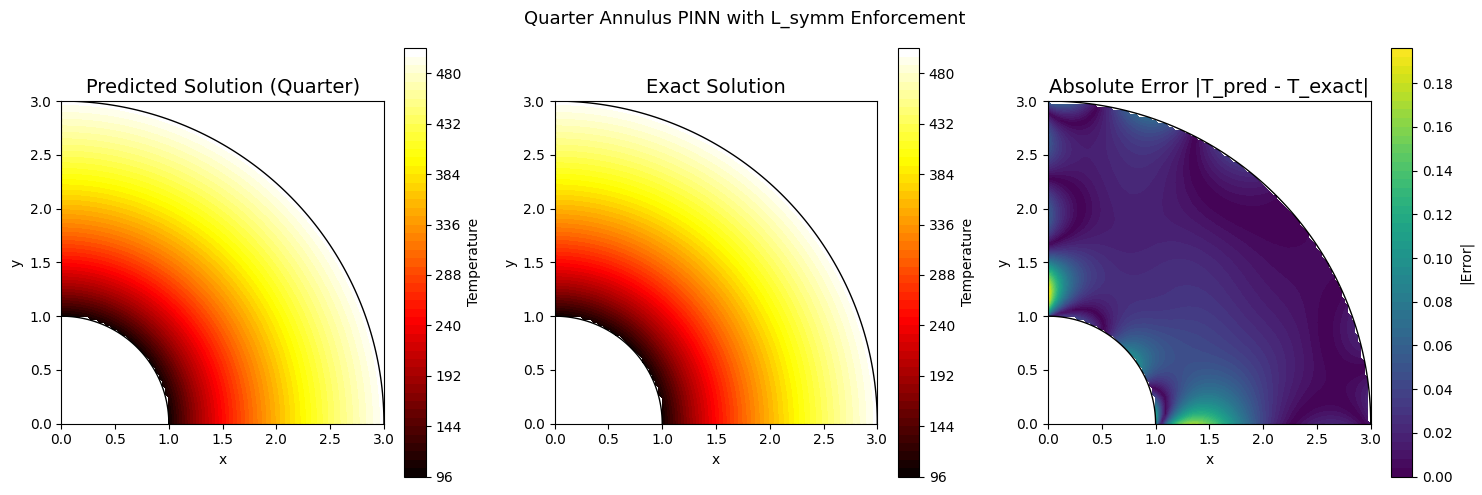

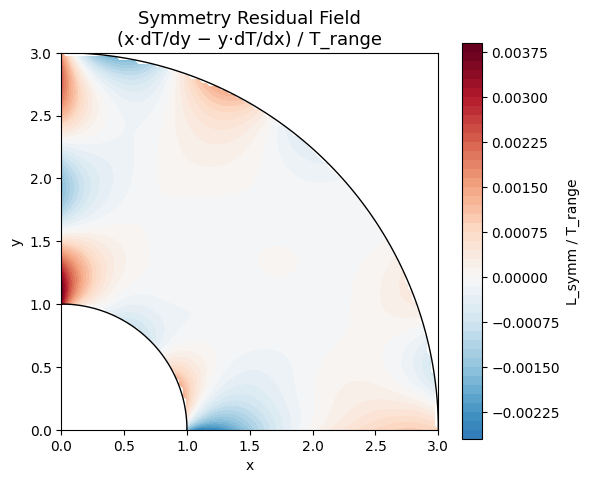

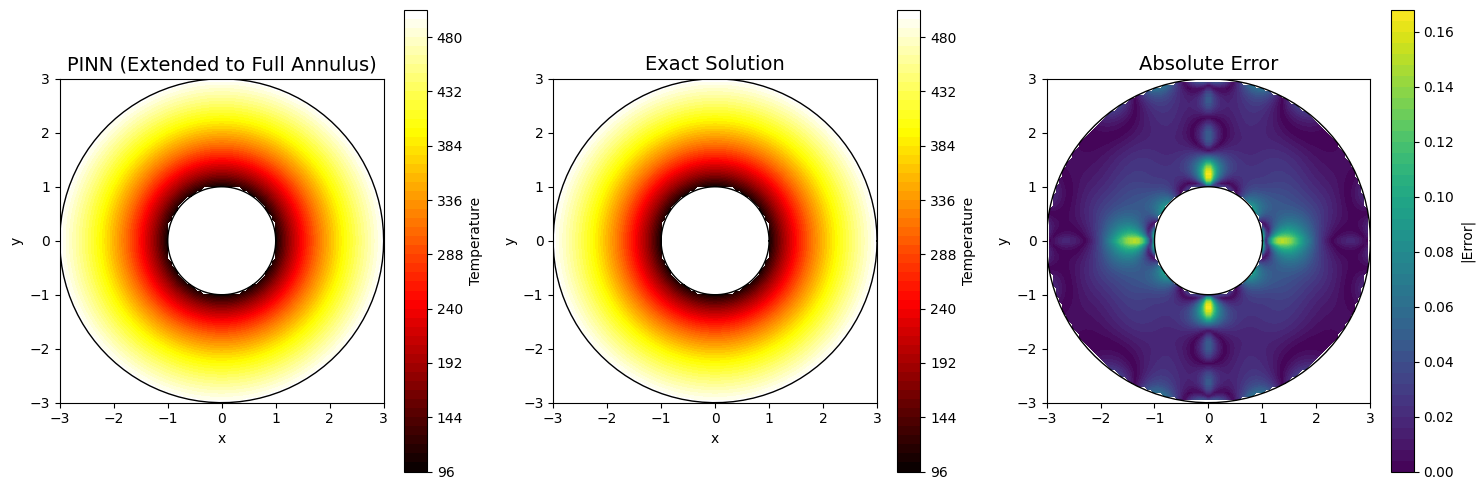

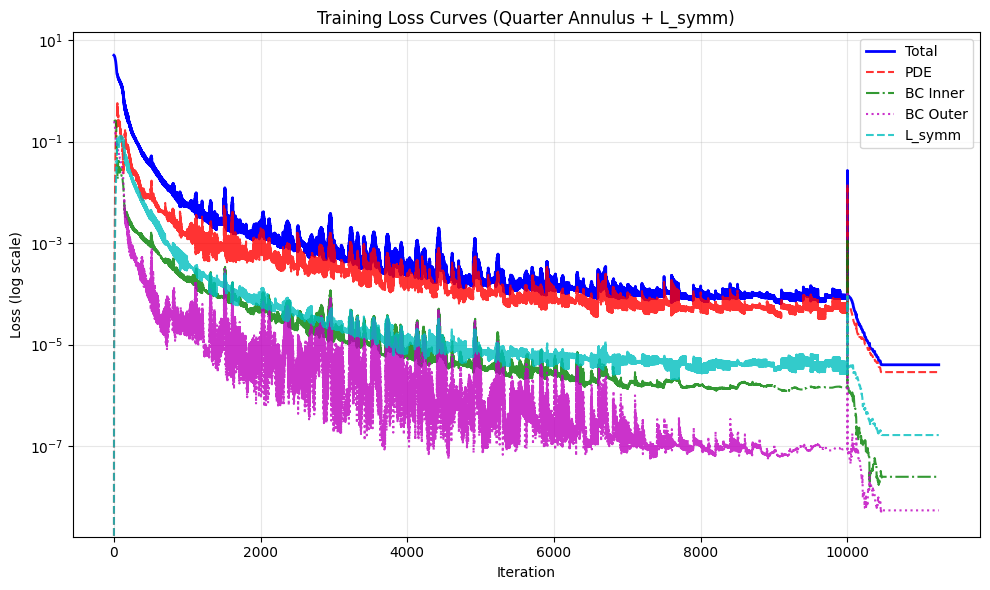

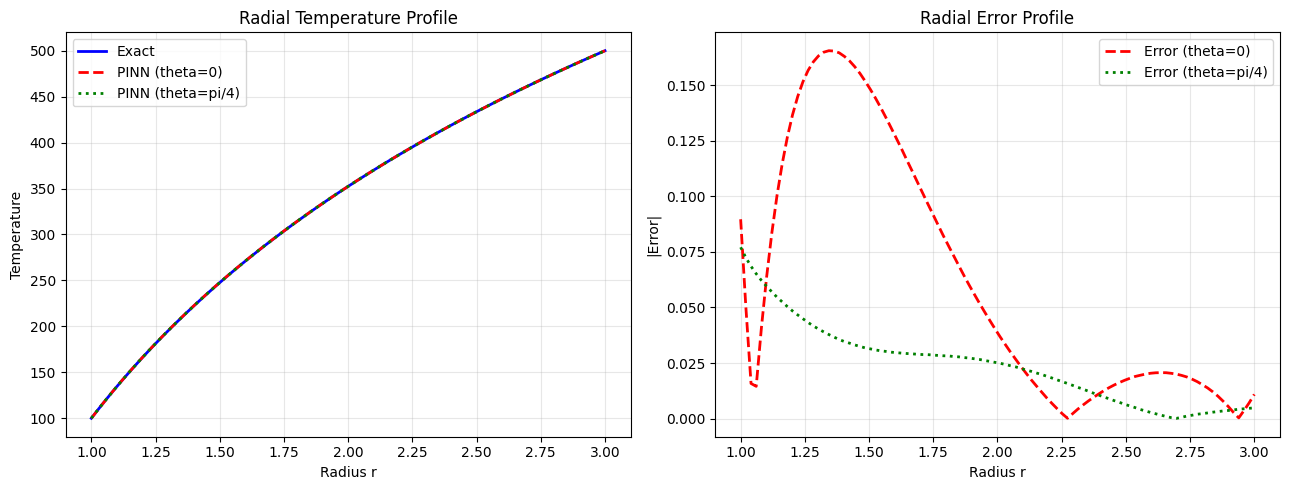

In [ ]:
def run_pinn(
    R1: float = 1.0,
    R2: float = 3.0,
    T_cold: float = 100.0,
    T_hot: float = 500.0,
    hidden_layers: int = 4,
    neurons_per_layer: int = 32,
    adam_iterations: int = 10000,
    lbfgs_iterations: int = 3000,
    lambda_pde: float = 1.0,
    lambda_bc: float = 10.0,
    lambda_symm: float = 5.0
) -> Tuple[PINN, dict, float, float]:
    """
    Run complete PINN training and visualization for quarter annulus
    with volumetric L_symm symmetry enforcement.
    """

    config = Config(
        R1=R1, R2=R2,
        T_cold=T_cold, T_hot=T_hot,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        adam_iterations=adam_iterations,
        lbfgs_iterations=lbfgs_iterations,
        lambda_pde=lambda_pde,
        lambda_bc=lambda_bc,
        lambda_symm=lambda_symm
    )

    print(config)

    model = PINN(config).to(config.device)
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    trainer = Trainer(config, model)
    trainer.train()

    analytics = Analytics(config)
    abs_err, rel_err = analytics.compute_l2_error(model)
    lsymm_rms = analytics.compute_lsymm_error(model)

    print(f"\n{'='*65}")
    print(f"Error Metrics:")
    print(f"  Absolute L2 Error : {abs_err:.4e}")
    print(f"  Relative L2 Error : {rel_err:.4%}")
    print(f"  L_symm RMS        : {lsymm_rms:.4e}  (0 = perfect radial symmetry)")
    print(f"  Training Time     : {trainer.training_time:.2f} s")
    print(f"{'='*65}")

    visualizer = Visualizer(config)
    visualizer.plot_solution(model, analytics)
    visualizer.plot_lsymm_field(model)
    visualizer.plot_full_annulus(model, analytics)
    visualizer.plot_loss_curves(trainer.history)
    visualizer.plot_radial_profile(model, analytics)

    return model, trainer.history, abs_err, rel_err


if __name__ == "__main__":
    model, history, abs_err, rel_err = run_pinn(
        R1=1.0,
        R2=3.0,
        T_cold=100.0,
        T_hot=500.0,
        hidden_layers=4,
        neurons_per_layer=32,
        adam_iterations=10000,
        lbfgs_iterations=3000,
        lambda_pde=1.0,
        lambda_bc=10.0,
        lambda_symm=5.0
    )